In [2]:
# Imports

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table, unique, join

In [3]:
# Gray field stars as points, colored cluster members

def plot_membership(data):
    with fits.open(data) as hdul:
        data = hdul[1].data

    bp_rp = data["GAIAEDR3_BP"] - data["GAIAEDR3_RP"]
    G = data["GAIAEDR3_G"]
    dist = data["dist"]
    MG = G - 5*np.log10(dist) + 5

    mem = data["MemBool"] == 1
    field = data["MemBool"] != 1

    plt.scatter(bp_rp[mem], MG[mem], s=3, marker='o', zorder=2)
    plt.plot(bp_rp[field], MG[field], '.', color='0.8', markersize=3, zorder=1)
   
    plt.xlabel("BP - RP")
    plt.ylabel("M_G")
    plt.gca().invert_yaxis()

    plt.show()

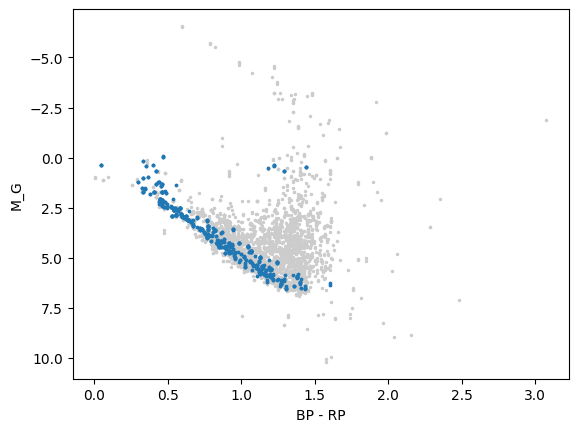

In [4]:
plot_membership("rcat_ngc6866_v0.fits")